In [110]:
import pandas as pd

# Read the dataset
df = pd.read_csv("Salary_Data.csv")

# View first 5 rows
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["YearsExperience"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [112]:
y_pred = model.predict(X_test)
print(y_pred)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


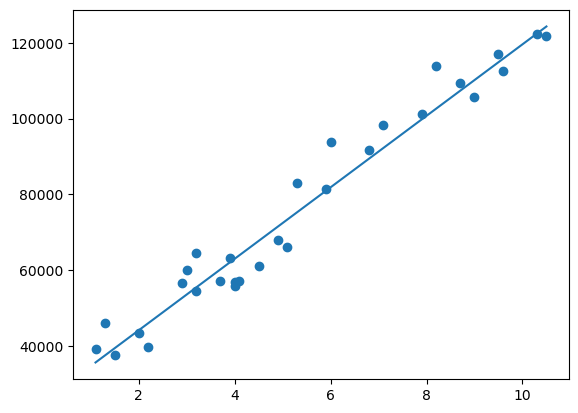

In [113]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.plot(X,model.predict(X))
plt.show()

In [114]:
from sklearn.metrics import mean_absolute_error

print("Actual Marks")
print(y_test.values)

print("\nPredicted Marks")
print(y_pred)

mae = mean_absolute_error(y_test,y_pred)

print("MAE:",mae)

Actual Marks
[112635.  67938. 113812.  83088.  64445.  57189.]

Predicted Marks
[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]
MAE: 6286.453830757749


In [115]:
mse = sum((actual - predicted)**2 for actual, predicted in zip(y_test, y_pred))/ len(y_test)
print("MSE:",mse)

MSE: 49830096.85590839


In [116]:
import math
rmse = math.sqrt(mse)
print("RMSE:",rmse)

RMSE: 7059.04362190151


In [117]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print("R2 Score :", r2)


R2 Score : 0.9024461774180497


In [118]:
from sklearn.model_selection import train_test_split
df["High_Salary"] = (df["Salary"] >= df["Salary"].median()).astype(int)

X = df[["YearsExperience"]]
y = df["High_Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [119]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [120]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 1 1 0 0]


In [121]:
from sklearn.tree import DecisionTreeClassifier
X = df[["YearsExperience","Salary"]]
y = df["High_Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [122]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [123]:
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 1 0 0]


In [125]:
from sklearn.ensemble import RandomForestClassifier

X = df[["YearsExperience","Salary"]]
y = df["High_Salary"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted Test Values:")
print(y_pred)

prediction = model.predict([[6, 85]])

print("Prediction :", prediction)

Predicted Test Values:
[1 1 1 1 0 0]
Prediction : [0]


C:\Users\hello\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
